In [2]:
import os, sys
import torch
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("")), 'src'))
from data_loader import DiffusionDataset, get_diffusion_dataloader, visualize_image_channels



In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ----------------------------------------------------------------
# 1) GLOBAL rcParams / STYLE SETTINGS
# ----------------------------------------------------------------
plt.rcParams.update({
    # Figure
    "figure.figsize":       (10.0, 8.0),       # Taller for two rows: 10" wide × 8" tall
    "figure.dpi":           100,

    # Fonts (use default serif, let Matplotlib pick DejaVu Serif)
    "font.family":          "serif",
    # "font.serif":         ["Computer Modern"],  # <-- remove or comment out if CM isn't installed
    "font.size":            12.0,
    "mathtext.fontset":     "cm",               # math glyphs still in CM style

    # Axes
    "axes.titlesize":       12.0,
    "axes.labelsize":       12.0,
    "axes.linewidth":       1.0,
    "axes.edgecolor":       "black",

    # Tick labels
    "xtick.labelsize":      11.0,
    "ytick.labelsize":      11.0,
    "xtick.direction":      "out",
    "ytick.direction":      "out",
    "xtick.major.size":     5.0,
    "ytick.major.size":     5.0,
    "xtick.minor.size":     3.0,
    "ytick.minor.size":     3.0,

    # Legend
    "legend.fontsize":      10.0,
    "legend.frameon":       True,
    "legend.framealpha":    1.0,
    "legend.edgecolor":     "black",

    # Lines
    "lines.linewidth":      1.5,
    "lines.markersize":     6.0,

    # Savefig
    "savefig.bbox":         "tight",
    "savefig.dpi":          300,
})

# ----------------------------------------------------------------
# 2) CUSTOM X‐TICK FORMATTER (only label integer timesteps)
# ----------------------------------------------------------------
def integer_formatter(x_val, pos):
    """
    Only return a label if x_val is (nearly) an integer.
    Otherwise return empty string.
    """
    if abs(x_val - round(x_val)) < 1e-6:
        return f"{int(x_val)}"
    return ""

int_fmt = FuncFormatter(integer_formatter)

Source shape: torch.Size([5, 512, 512])
Target shape: torch.Size([5, 512, 512])


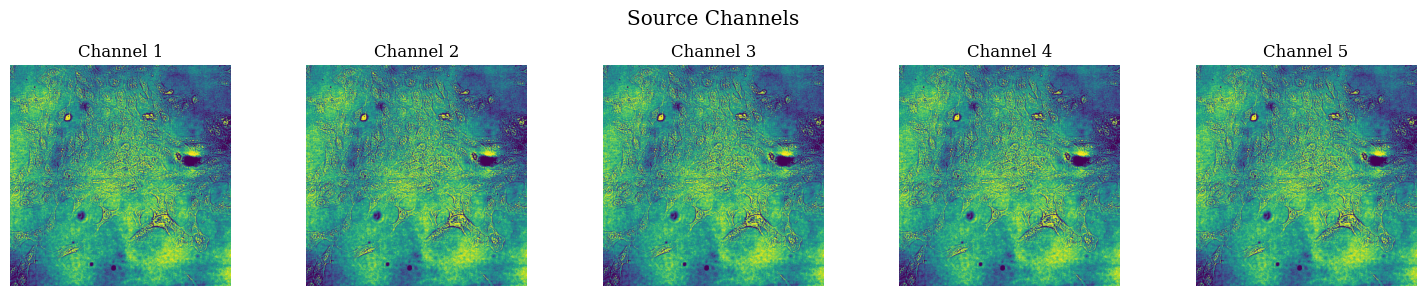

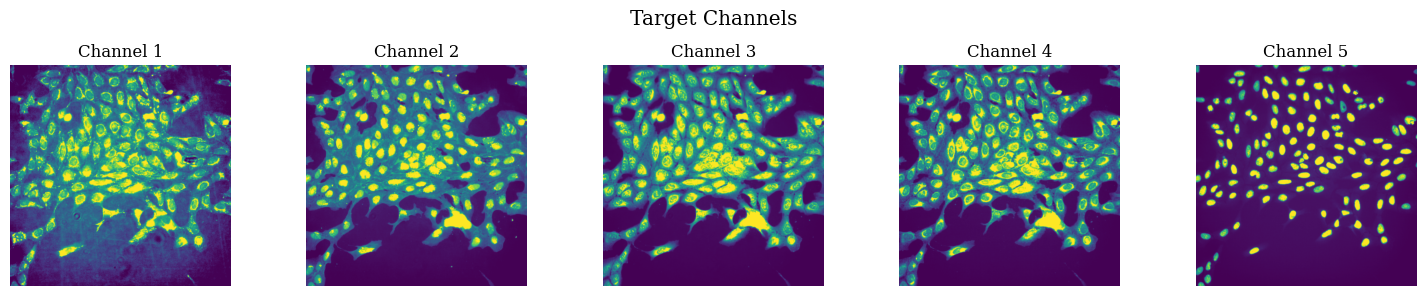

In [4]:


# 1) Point to the CSV that lists your partial paths for the dummy data:
csv_list = [os.path.join('..', "tests", "sdfsd_dummy data.csv")]

# 2) Create the dataset (channels 1–3 as “source”, 4–6 as “target”):
dataset = DiffusionDataset(
    csv_file_list=csv_list,
    images_dir=os.path.join('..', "tests",),
    source_channels=[7, 7, 7, 7, 7],
    target_channels=[1, 2, 3, 4, 5],
    img_size=(512,512)
)

# 3) Pull out one sample:
src_tensor, tgt_tensor = dataset[0]
print("Source shape:", src_tensor.shape)   # e.g. (3, 512, 512)
print("Target shape:", tgt_tensor.shape)   # e.g. (3, 512, 512)

# 4) Visualize if you like:
visualize_image_channels(src_tensor, title="Source Channels")
visualize_image_channels(tgt_tensor, title="Target Channels")


-0.1556999 1.1336694
-2.9198601 3.5223572
-4.8646483 6.4480004
-8.234571 9.499657


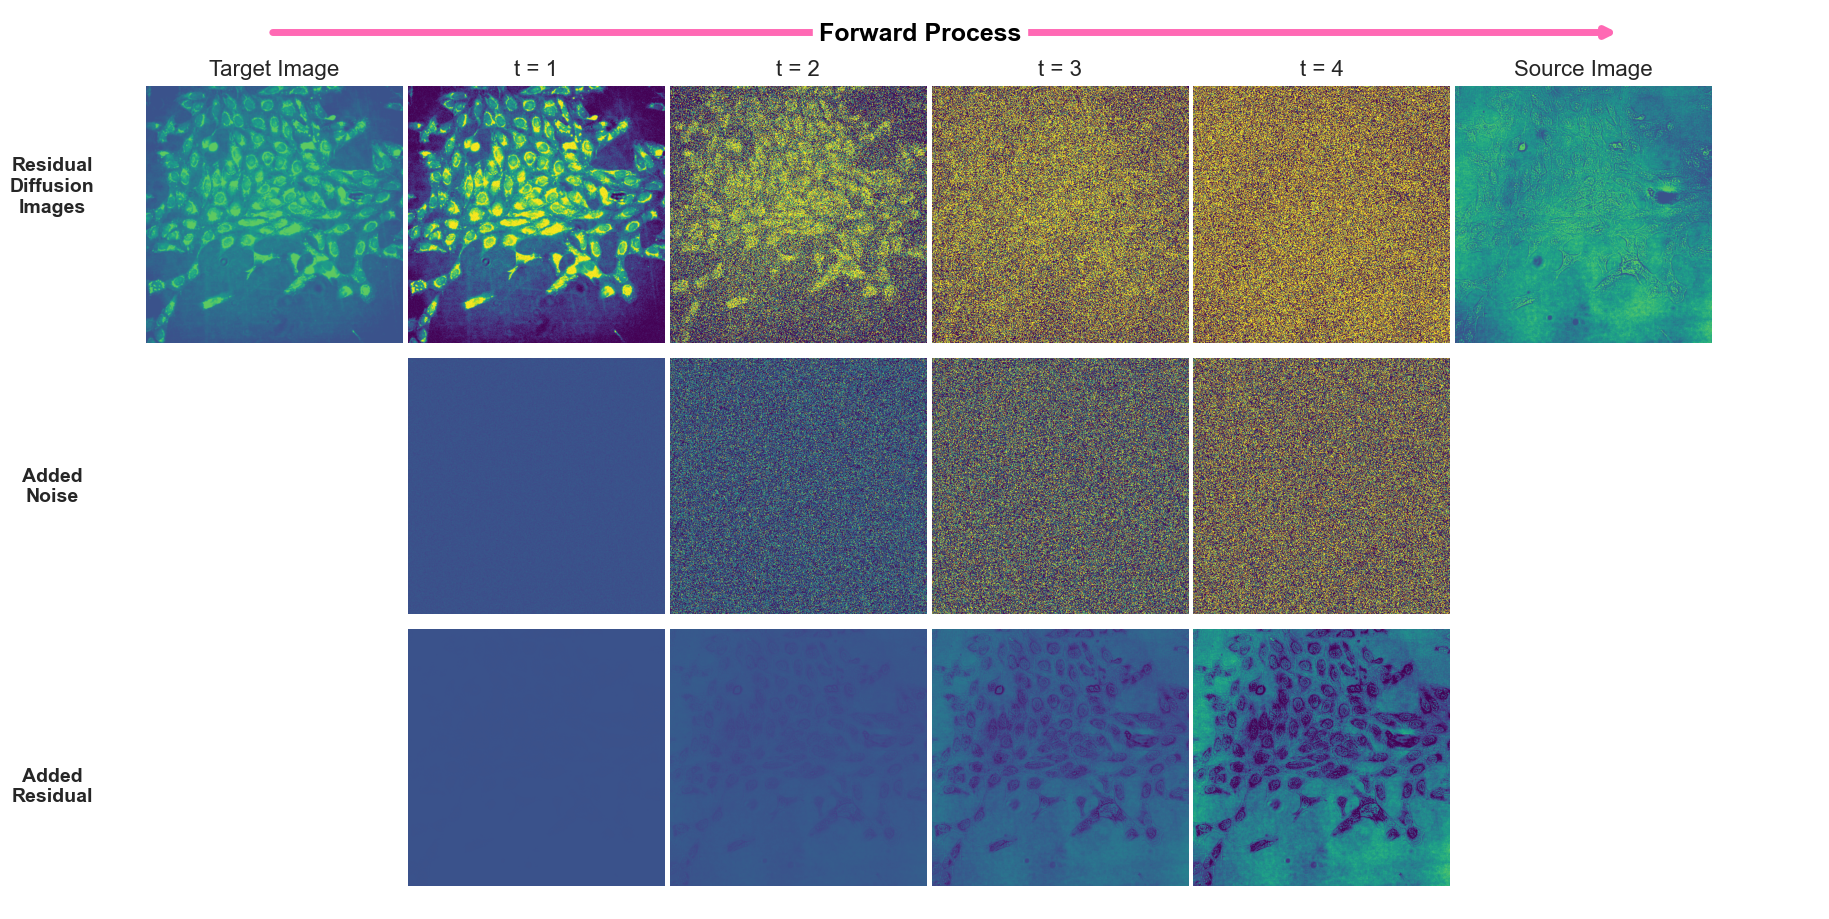

In [18]:
# get noisy image

import matplotlib.pyplot as plt 
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("")), 'src'))
from noise_scheduling import CFG, DiffusionScheduler

config = CFG(kappa=2.0, p=0.3, eta_T=0.99, T=4)
scheduler = DiffusionScheduler(config)

# Stack the "noisy residual" outputs for timesteps 1..15
noisy_residuals = []
for t in range(1, 5):
    nr = scheduler.get_noisy_image(t, tgt_tensor, src_tensor)  # shape [1, H, W]
    noisy_residuals.append(nr.unsqueeze(1))  # shape [1,1,H,W]
noisy_residuals = torch.cat(noisy_residuals, dim=1)  # shape [1,15,H,W]

# ----------------------------------------------------------------
# 4) CREATE A 3×17 GRID:
#      - Column 0: "Target" (only row0)
#      - Columns 1–15: timesteps 1..15 (rows 0–2)
#      - Column 16: "Source" (only row0)
# ----------------------------------------------------------------
n_rows = 3
n_cols =6  # 15 original + 1 left + 1 right

# We choose figsize so that each column is ~3″ wide (like your original 15×3=45″),
# plus same height per row (9″ total). Now 17 columns → width = 17×3 = 51.
fig, ax = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(18, 9)
)

# ----------------------------------------------------------------
# 5) PLOT "TARGET" in LEFTMOST COLUMN (col_index = 0, row = 0)
# ----------------------------------------------------------------
# Display only in row 0. Turn off axes in row 1 & 2 of col 0.
ax[0, 0].imshow(tgt_tensor[0].cpu().numpy(), vmin=-0.5, vmax=1.5, cmap='viridis')
ax[0, 0].set_title("Target Image", fontsize=16, pad=8)
ax[0, 0].axis("off")

# Turn off rows 1 & 2 in column 0 (blank subplots)
for r in [1, 2]:
    ax[r, 0].axis("off")

# ----------------------------------------------------------------
# 6) PLOT THE 15 TIMESTEPS IN COLUMNS 1..15
#      - Row 0: "Noisy residual image"
#      - Row 1: "Noise"
#      - Row 2: "Residual"
# ----------------------------------------------------------------
for t in range(1, 5):
    col_idx = t  # columns 1..15

    # Row 0: Noisy residual
    nr_img = noisy_residuals[0, t - 1].cpu().numpy()  # shape [H, W]
    ax[0, col_idx].imshow(nr_img, vmin=0, vmax=1, cmap='viridis')
    ax[0, col_idx].axis("off")

    # Row 1: "Noise"  = κ * sqrt(η_t) * ε
    eta_t_val = float(scheduler.get_eta_t(t).detach().cpu())
    noise = torch.randn_like(src_tensor)  # shape [1, H, W]
    noise_term = config.kappa * np.sqrt(eta_t_val) * noise  # shape [1, H, W]
    ax[1, col_idx].imshow(noise_term[0].cpu().numpy(), vmin=-0.5, vmax=1.5, cmap='viridis')
    ax[1, col_idx].axis("off")

    # Row 2: "Residual"  = η_t * (src – tgt)
    resid_term = eta_t_val * (src_tensor - tgt_tensor)  # shape [1, H, W]
    ax[2, col_idx].imshow(resid_term[0].cpu().numpy(), vmin=-0.5, vmax=1.5, cmap='viridis')
    ax[2, col_idx].axis("off")
    print(
        nr_img.min(), nr_img.max(),
    )

# ----------------------------------------------------------------
# 7) PLOT "SOURCE" in RIGHTMOST COLUMN (col_index = 16, row = 0)
# ----------------------------------------------------------------
ax[0, 5].imshow(src_tensor[0].cpu().numpy(), vmin=-0.5, vmax=1.5, cmap='viridis')
ax[0, 5].set_title("Source Image", fontsize=16, pad=8)
ax[0, 5].axis("off")

# Turn off rows 1 & 2 in column 16
for r in [1, 2]:
    ax[r, 5].axis("off")

# ----------------------------------------------------------------
# 8) ADD ROW LABELS ("Noised residual", "Noise", "Residual")
#    We place them to the left of the first "active" image column (col 1),
#    at the vertical center of each row's subplots.
# ----------------------------------------------------------------
# Compute normalized figure‐fraction y‐positions for each row:
# (Row indices go 0→top, 2→bottom. We want centers.)
row_centers = [
    1 - (0.5 / n_rows),  # center of row 0 (slightly below top edge)
    1 - (1.5 / n_rows),  # center of row 1
    1 - (2.5 / n_rows),  # center of row 2 (slightly above bottom)
]

for idx, label in enumerate(["Residual\nDiffusion\nImages", "Added\nNoise", "Added\nResidual"]):
    fig.text(
        0.018,                   # x‐position in figure coords (just left of col 1)
        row_centers[idx] - 0.03,        # y‐position
        label,
        va="center",
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

# ----------------------------------------------------------------
# 9) ADD COLUMN LABELS FOR "Timesteps 1…15" BELOW ROW 2
#    We place a small "t=1, …, t=15" note under each column 1..15
# ----------------------------------------------------------------
for t in range(1, 5):
    ax[0, t].set_title(f"t = {t}", fontsize=16, pad=8)

ax_arrow = fig.add_axes([0, 0, 1, 1], frameon=False)  # spans the entire figure
ax_arrow.axis("off")

# Draw the arrow from left of col 1 (≈ x=0.12) to right of col 4 (≈ x=0.78) at y=0.96
ax_arrow.annotate(
    "",
    xy=(0.9, 0.985),            # tip (right)
    xytext=(0.15, 0.985),        # tail (left)
    xycoords="figure fraction",
    textcoords="figure fraction",
    arrowprops=dict(
        arrowstyle="->",
        color="hotpink",
        linewidth=5
    )
)
# Add label "Forward Process" above the arrow
fig.text(
    0.5,                       # centered between 0.12 and 0.78
    0.96,                       # just below the top edge
    "Forward Process",
    va="bottom",
    ha="center",
    color="Black",
    fontsize=18,
    fontweight="bold",
    backgroundcolor="white"
)
# ----------------------------------------------------------------
# 10) TIGHT LAYOUT & DISPLAY
# ----------------------------------------------------------------
plt.subplots_adjust(
    left=0.07,      # give room for row labels
    right=0.94,
    top=0.92,
    bottom=0.02,
    wspace=0.02,    # minimal horizontal spacing between columns
    hspace=0.02     # minimal vertical spacing between rows
)
plt.show()


c:\Users\yuche\OneDrive\Documents\Brain in a vat\CAM Mphil\DIS_final_project\src\noise_scheduling.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  numerator = torch.tensor(t - 1, dtype=torch.float32)
C:\Users\yuche\AppData\Local\Temp\ipykernel_29436\1801814496.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


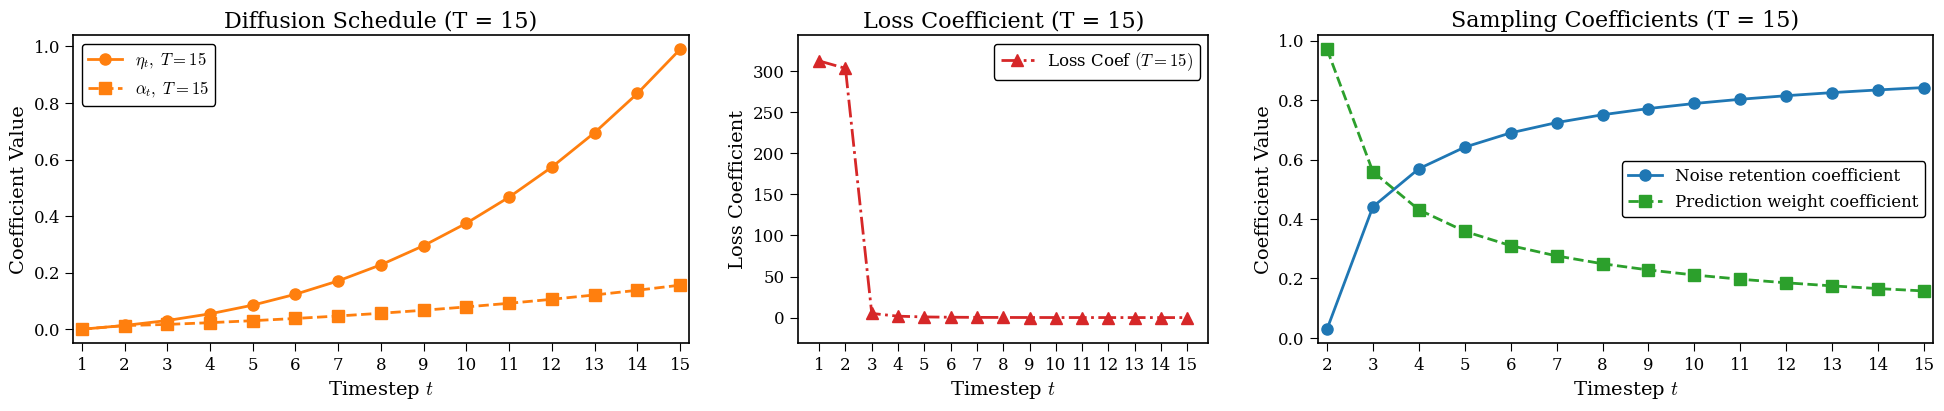

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec

# ----------------------------------------------------------------
# 1) INTEGER TICK FORMATTER (only label exact integers)
# ----------------------------------------------------------------
def integer_formatter(x_val, pos):
    if abs(x_val - round(x_val)) < 1e-6:
        return f"{int(x_val)}"
    return ""
int_fmt = FuncFormatter(integer_formatter)

# ----------------------------------------------------------------
# 2) COMPUTE SCHEDULER DATA FOR T=15
#    (Assumes CFG and DiffusionScheduler are imported already)
# ----------------------------------------------------------------
# T=15: η_t and α_t
T_bot = 15
config_bot = CFG(kappa=2.0, p=0.3, eta_T=0.99, T=T_bot)
scheduler_bot = DiffusionScheduler(config_bot)
time_steps_bot = torch.arange(1, T_bot + 1, dtype=torch.float32)

eta_bot   = np.array([float(scheduler_bot.get_eta_t(t).detach().cpu()) for t in time_steps_bot])
alpha_bot = np.array([float(scheduler_bot.get_alpha_t(t).detach().cpu()) for t in time_steps_bot])

# T=15: loss coefficient
loss_bot = np.array([float(scheduler_bot.get_loss_coef(t).detach().cpu()) for t in time_steps_bot])

# T=15: sampling coefficients (for t >= 2 since we need t-1)
time_steps_sample = torch.arange(2, T_bot + 1, dtype=torch.float32)
coef_1 = np.array([float((scheduler_bot.get_eta_t(t - 1) / scheduler_bot.get_eta_t(t)).detach().cpu()) for t in time_steps_sample])
coef_2 = np.array([float((scheduler_bot.get_alpha_t(t) / scheduler_bot.get_eta_t(t)).detach().cpu()) for t in time_steps_sample])

# ----------------------------------------------------------------
# 3) SET GLOBAL STYLE (fonts, line widths)
# ----------------------------------------------------------------
plt.rcParams.update({
    "font.family":      "serif",
    # "font.serif":     ["Computer Modern"],  # uncomment if CM installed
    "font.size":        14.0,
    "mathtext.fontset": "cm",
    "axes.titlesize":   16.0,
    "axes.labelsize":   14.0,
    "axes.linewidth":   1.2,
    "xtick.labelsize":  12.0,
    "ytick.labelsize":  12.0,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
    "xtick.major.size": 6.0,
    "ytick.major.size": 6.0,
    "legend.fontsize":  12.0,
    "lines.linewidth":  2.0,
    "lines.markersize": 8.0,
    "savefig.bbox":     "tight",
    "savefig.dpi":      300,
})

# ----------------------------------------------------------------
# 4) CREATE FIGURE WITH GRIDSPEC (1 row × 3 cols)
#    Left column: η_t and α_t for T=15
#    Middle column: loss coefficient for T=15
#    Right column: sampling coefficients for T=15
# ----------------------------------------------------------------
fig = plt.figure(figsize=(24, 4), dpi=100)
gs = GridSpec(nrows=1, ncols=3, width_ratios=[6, 4, 6], 
              wspace=0.2)

# Left: η_t and α_t for T=15
ax_schedule = fig.add_subplot(gs[0, 0])
# Middle: loss coefficient for T=15
ax_loss = fig.add_subplot(gs[0, 1])
# Right: sampling coefficients for T=15
ax_sample = fig.add_subplot(gs[0, 2])

# ----------------------------------------------------------------
# 5) PLOT η_t and α_t FOR T=15 (ax_schedule)
# ----------------------------------------------------------------
ax_schedule.plot(
    time_steps_bot.numpy(),
    eta_bot,
    color="tab:orange",
    linestyle="-",
    marker="o",
    label=r"$\eta_t,\;T=15$"
)
ax_schedule.plot(
    time_steps_bot.numpy(),
    alpha_bot,
    color="tab:orange",
    linestyle="--",
    marker="s",
    label=r"$\alpha_t,\;T=15$"
)

ax_schedule.set_title("Diffusion Schedule (T = 15)")
ax_schedule.set_xlabel("Timestep $t$")
ax_schedule.set_ylabel("Coefficient Value")
ax_schedule.set_xticks(np.arange(1, T_bot + 1, 1))
ax_schedule.xaxis.set_major_formatter(int_fmt)
ax_schedule.set_xlim(1 - 0.2, T_bot + 0.2)
ax_schedule.legend(loc="upper left", frameon=True, borderaxespad=0.5)

# ----------------------------------------------------------------
# 6) PLOT LOSS COEFFICIENT FOR T=15 (ax_loss)
# ----------------------------------------------------------------
ax_loss.plot(
    time_steps_bot.numpy(),
    loss_bot,
    color="tab:red",
    linestyle="-.",
    marker="^",
    label=r"Loss Coef $(T=15)$"
)

# Add some internal padding on y-axis
ymin, ymax = loss_bot.min(), loss_bot.max()
yrange = ymax - ymin
ypad = 0.10 * yrange
ax_loss.set_ylim(ymin - ypad, ymax + ypad)

ax_loss.set_title("Loss Coefficient (T = 15)")
ax_loss.set_xlabel("Timestep $t$")
ax_loss.set_ylabel("Loss Coefficient")
ax_loss.set_xticks(np.arange(1, T_bot + 1, 1))
ax_loss.xaxis.set_major_formatter(int_fmt)
ax_loss.set_xlim(1 - 0.8, T_bot + 0.8)
ax_loss.legend(loc="upper right", frameon=True, borderaxespad=0.5)

# ----------------------------------------------------------------
# 7) PLOT SAMPLING COEFFICIENTS FOR T=15 (ax_sample)
# ----------------------------------------------------------------
# Plot the diffusion interpolation coefficients over time
ax_sample.plot(
    time_steps_sample.numpy(),
    coef_1,
    color="tab:blue",
    linestyle="-",
    marker="o",
    label="Noise retention coefficient"
)
ax_sample.plot(
    time_steps_sample.numpy(),
    coef_2,
    color="tab:green",
    linestyle="--",
    marker="s",
    label="Prediction weight coefficient"
)


ax_sample.set_title("Sampling Coefficients (T = 15)")
ax_sample.set_xlabel("Timestep $t$")
ax_sample.set_ylabel("Coefficient Value")
ax_sample.set_xticks(np.arange(2, T_bot + 1, 1))
ax_sample.xaxis.set_major_formatter(int_fmt)
ax_sample.set_xlim(2 - 0.2, T_bot + 0.2)
ax_sample.legend(loc="best", frameon=True, borderaxespad=0.5)

# ----------------------------------------------------------------
# 8) TIGHT LAYOUT & SHOW
# ----------------------------------------------------------------
plt.tight_layout()
plt.show()


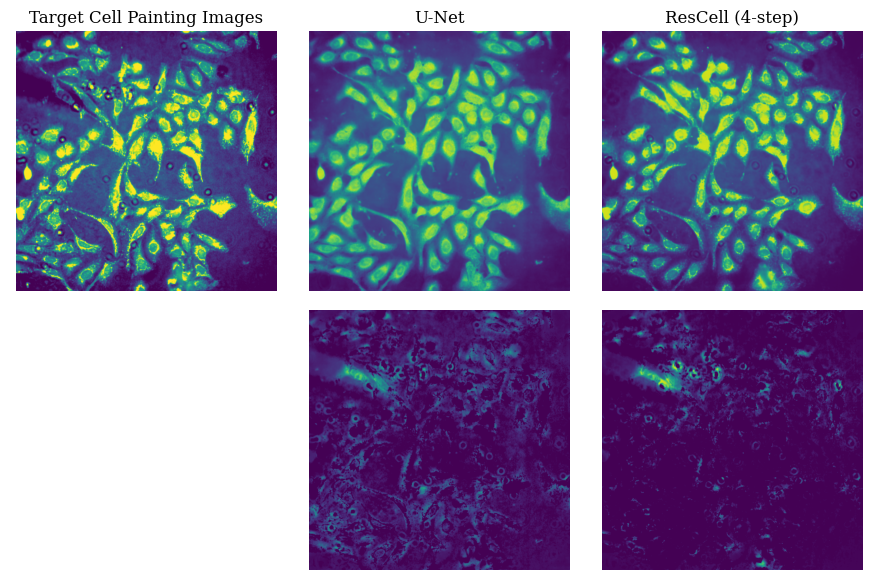

In [7]:
# unet_pred = n
from matplotlib import pyplot as plt


# load temp_check\r01c01f01p01_pred (1).npy
target = np.load("..\\temp_check\\r01c01f01p01_target (1).npy")

unet_pred = np.load("..\\temp_check\\r01c01f01p01_pred (1).npy")
rescell_pred = np.load("..\\temp_check\\r01c01f01p01_pred (2).npy")


# normalize the pred to 0-1
unet_pred = (unet_pred - unet_pred.min()) / (unet_pred.max() - unet_pred.min())
rescell_pred = (rescell_pred - rescell_pred.min()) / (rescell_pred.max() - rescell_pred.min())

results = [
    unet_pred,
    rescell_pred
]

fig, ax = plt.subplots(2, len(results) + 1, figsize=(3 * (len(results) + 1), 6))

for i, result in enumerate(results):
    ax[0, i + 1].imshow(result[0], vmin=0, vmax=1)
    ax[1, i + 1].imshow(result[0] - target[0], vmin=0, vmax=1)

ax[0, 0].imshow(target[0])

for i in range(len(results) + 1):
    ax[0, i].axis("off")
    ax[1, i].axis("off")

for idx, text in enumerate([
    "Target Cell Painting Images",
    "U-Net",
    "ResCell (4-step)",
]):
    ax[0, idx].set_title(text, fontsize=12)


plt.tight_layout()
plt.show()



,mse_255,ssim_255,psnr_255
model,,,
CellResDM (SDVAE),1451.273024,0.474518,16.743364
"ResCell (15 step, wo Loss Coef)",734.552612,0.727595,20.243149
"ResCell Ablation (15 step, No LPIPS)",1573.790908,0.548789,16.651565
"ResCell Ablation (15 step, No LPIPS, One Step)",568.657275,0.767551,21.979214
"ResCell Ablation (15 step, w Loss Coef)",878.006134,0.688939,19.158457
Unet,1140.487330,0.622066,18.990290
pix2pix,1626.089031,0.433389,16.436490


,mse_255,ssim_255,psnr_255
model,,,
CellResDM (SDVAE),521.546345,0.088980,1.389299
"ResCell (15 step, wo Loss Coef)",543.328039,0.118800,2.486131
"ResCell Ablation (15 step, No LPIPS)",802.997003,0.099783,2.062668
"ResCell Ablation (15 step, No LPIPS, One Step)",1136.123761,0.125528,2.584149
"ResCell Ablation (15 step, w Loss Coef)",509.034726,0.108261,1.907602
Unet,1908.325426,0.100912,2.690378
pix2pix,829.496691,0.087337,1.834833


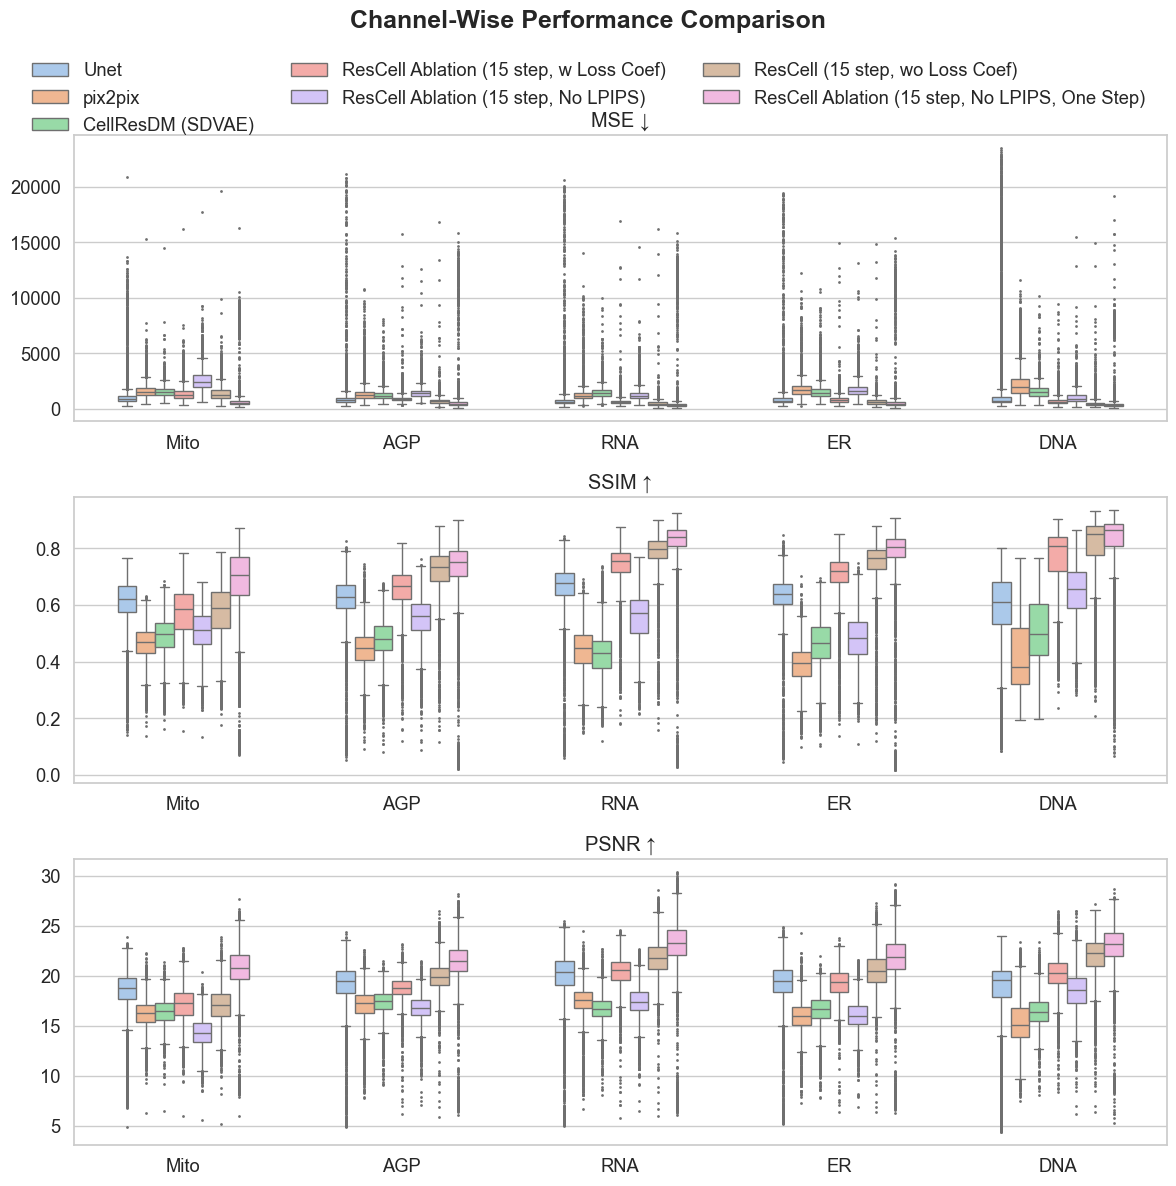

In [8]:
import pandas as pd

df = pd.read_csv('./results/metrics_unet.csv')
df['model'] = 'Unet'

df1 = pd.read_csv('./results/metrics_pix2pix.csv')
df1['model'] = 'pix2pix'


df2 = pd.read_csv('./results/metrics_CellResDM_SDVAE_125.csv')
df2['model'] = 'CellResDM (SDVAE)'
df2['channel'] = df2['channel'].map({2: 4, 0:0, 1:1})

df3 = pd.read_csv('./results/metrics_CellResDM_SDVAE_345.csv')
df3['model'] = 'CellResDM (SDVAE)'
df3['channel'] = df3['channel'].map({0: 2, 1: 3, 2: 4})
df3
df3 = df3[df3['channel'] != 4]
# concatenate df2 and df3
df_cellresdm_sdvae = pd.concat([df2, df3])
df_cellresdm_sdvae


df6 = pd.read_csv('./results/metrics_final_corrected_version_15step_with_coef.csv')
df6['model'] = 'ResCell Ablation (15 step, w Loss Coef)'

df7 = pd.read_csv('./results/metrics_final_corrected_version_15step_no_lpips.csv')
df7['model'] = 'ResCell Ablation (15 step, No LPIPS)'

df8 = pd.read_csv('./results/metrics_final_corrected_version_15step.csv')
df8['model'] = 'ResCell (15 step, wo Loss Coef)'


df9 = pd.read_csv('./results/metrics_one_step.csv')
df9['model'] = 'ResCell Ablation (15 step, No LPIPS, One Step)'




# df6 = pd.read_csv('../metrics 15step cd.csv')
# df6['model'] = 'ResCell (15 step, wo Loss Coef, MSE+LPIPS CD)'

df = pd.concat([df, df1, df_cellresdm_sdvae, df6, df7, df8, df9], ignore_index=True)

# first print the mean per model per metric
display(df.groupby('model')[['mse_255', 'ssim_255', 'psnr_255']].mean())
display(df.groupby('model')[['mse_255', 'ssim_255', 'psnr_255']].std())

channel_map = {
    0: "Mito", 1: "AGP", 2: "RNA", 3: "ER", 4: "DNA"
}
df['channel'] = df['channel'].map(channel_map)

# If some channels are missing, drop NA
df = df.dropna(subset=['channel'])

metrics = {'mse_255': "MSE ↓", 'ssim_255': 'SSIM ↑', 'psnr_255' : 'PSNR ↑'}


import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.2)

fig, ax = plt.subplots(3, 1, figsize=(12, 12))
for idx, metric in enumerate(['mse_255', 'ssim_255', 'psnr_255']):
    sns.boxplot(x='channel', y=metric, hue = 'model', data=df, palette='pastel', showfliers=True, ax=ax[idx], fliersize = 1., width = 0.6)
    ax[idx].set_title(f'{metrics[metric]}')
    ax[idx].set_xlabel('')
    ax[idx].set_ylabel('')
    # disable legend
    ax[idx].legend_.remove()
    # sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    # title="Channel-Wise Performance Comparison",
    loc="upper center",
    ncol=len(df.model.unique())/2,  # Divide by 2 to create 2 rows
    frameon=False,
    bbox_to_anchor=(0.5, 0.96)
)
fig.suptitle("Channel-Wise Performance Comparison", fontsize=18, fontweight="bold", y=0.99)

# ----------------------------------------------------------------------------
# 6) ADJUST LAYOUT SO LEGEND SITS ABOVE
# ----------------------------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave top 7% for legend
plt.show()


,mse_255,ssim_255,psnr_255
model,,,
CellResDM (15 step),734.552612,0.727595,20.243149
CellResDM (2 step) Consistency Distilled,568.657275,0.767551,21.979214
DeepHSC,617.931932,0.793733,20.846888
Unet,1140.487330,0.622066,18.990290
pix2pix,1626.089031,0.433389,16.436490


,mse_255,ssim_255,psnr_255
model,,,
CellResDM (15 step),543.328039,0.118800,2.486131
CellResDM (2 step) Consistency Distilled,1136.123761,0.125528,2.584149
DeepHSC,473.575185,0.103164,2.138335
Unet,1908.325426,0.100912,2.690378
pix2pix,829.496691,0.087337,1.834833


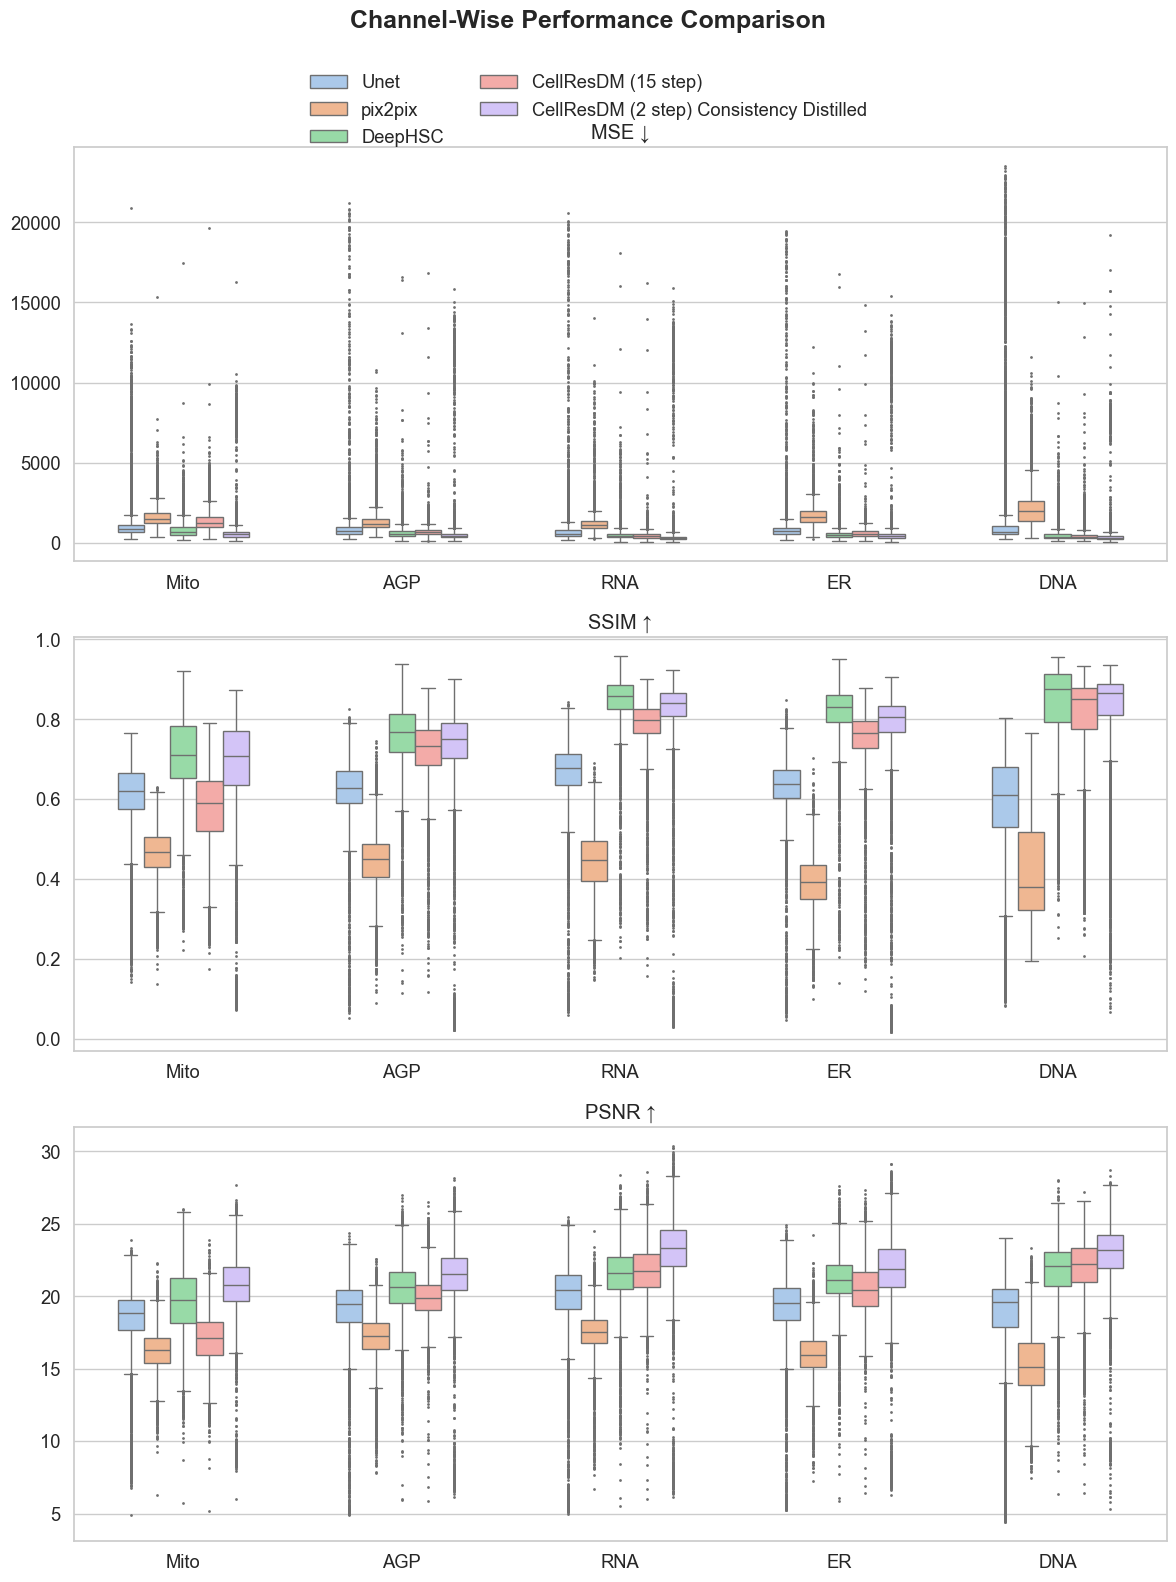

In [9]:
import pandas as pd

df = pd.read_csv('./results/metrics_unet.csv')
df['model'] = 'Unet'

df1 = pd.read_csv('./results/metrics_pix2pix.csv')
df1['model'] = 'pix2pix'

df2 = pd.read_csv('./results/metrics_deephsc.csv')
df2['model'] = 'DeepHSC'

df8 = pd.read_csv('./results/metrics_final_corrected_version_15step.csv')
df8['model'] = 'CellResDM (15 step)'


df9 = pd.read_csv('./results/metrics_one_step.csv')
df9['model'] = 'CellResDM (2 step) Consistency Distilled'




# df6 = pd.read_csv('../metrics 15step cd.csv')
# df6['model'] = 'ResCell (15 step, wo Loss Coef, MSE+LPIPS CD)'

df = pd.concat([df, df1, df2, df8, df9], ignore_index=True)

# first print the mean per model per metric
display(df.groupby('model')[['mse_255', 'ssim_255', 'psnr_255']].mean())
display(df.groupby('model')[['mse_255', 'ssim_255', 'psnr_255']].std())

channel_map = {
    0: "Mito", 1: "AGP", 2: "RNA", 3: "ER", 4: "DNA"
}
df['channel'] = df['channel'].map(channel_map)

# If some channels are missing, drop NA
df = df.dropna(subset=['channel'])

metrics = {'mse_255': "MSE ↓", 'ssim_255': 'SSIM ↑', 'psnr_255' : 'PSNR ↑'}


import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.2)

fig, ax = plt.subplots(3, 1, figsize=(12, 16))
for idx, metric in enumerate(['mse_255', 'ssim_255', 'psnr_255']):
    sns.boxplot(x='channel', y=metric, hue = 'model', data=df, palette='pastel', showfliers=True, ax=ax[idx], fliersize = 1., width = 0.6)
    ax[idx].set_title(f'{metrics[metric]}')
    ax[idx].set_xlabel('')
    ax[idx].set_ylabel('')
    # disable legend
    ax[idx].legend_.remove()
    # sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    # title="Channel-Wise Performance Comparison",
    loc="upper center",
    ncol=len(df.model.unique())/2,  # Divide by 2 to create 2 rows
    frameon=False,
    bbox_to_anchor=(0.5, 0.96)
)
fig.suptitle("Channel-Wise Performance Comparison", fontsize=18, fontweight="bold", y=0.99)

# ----------------------------------------------------------------------------
# 6) ADJUST LAYOUT SO LEGEND SITS ABOVE
# ----------------------------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave top 7% for legend
plt.show()


,mse_255,ssim_255,psnr_255
model,,,
CellResDM (15 step),734.552612,0.727595,20.243149
CellResDM (15 step) Ablation on no LPIPS,1573.790908,0.548789,16.651565
CellResDM (15 step) Ablation on with Loss Coef,878.006134,0.688939,19.158457
CellResDM (2 step) Consistency Distilled,568.657275,0.767551,21.979214
CellResDM (SDVAE),1451.273024,0.474518,16.743364


,mse_255,ssim_255,psnr_255
model,,,
CellResDM (15 step),543.328039,0.118800,2.486131
CellResDM (15 step) Ablation on no LPIPS,802.997003,0.099783,2.062668
CellResDM (15 step) Ablation on with Loss Coef,509.034726,0.108261,1.907602
CellResDM (2 step) Consistency Distilled,1136.123761,0.125528,2.584149
CellResDM (SDVAE),521.546345,0.088980,1.389299


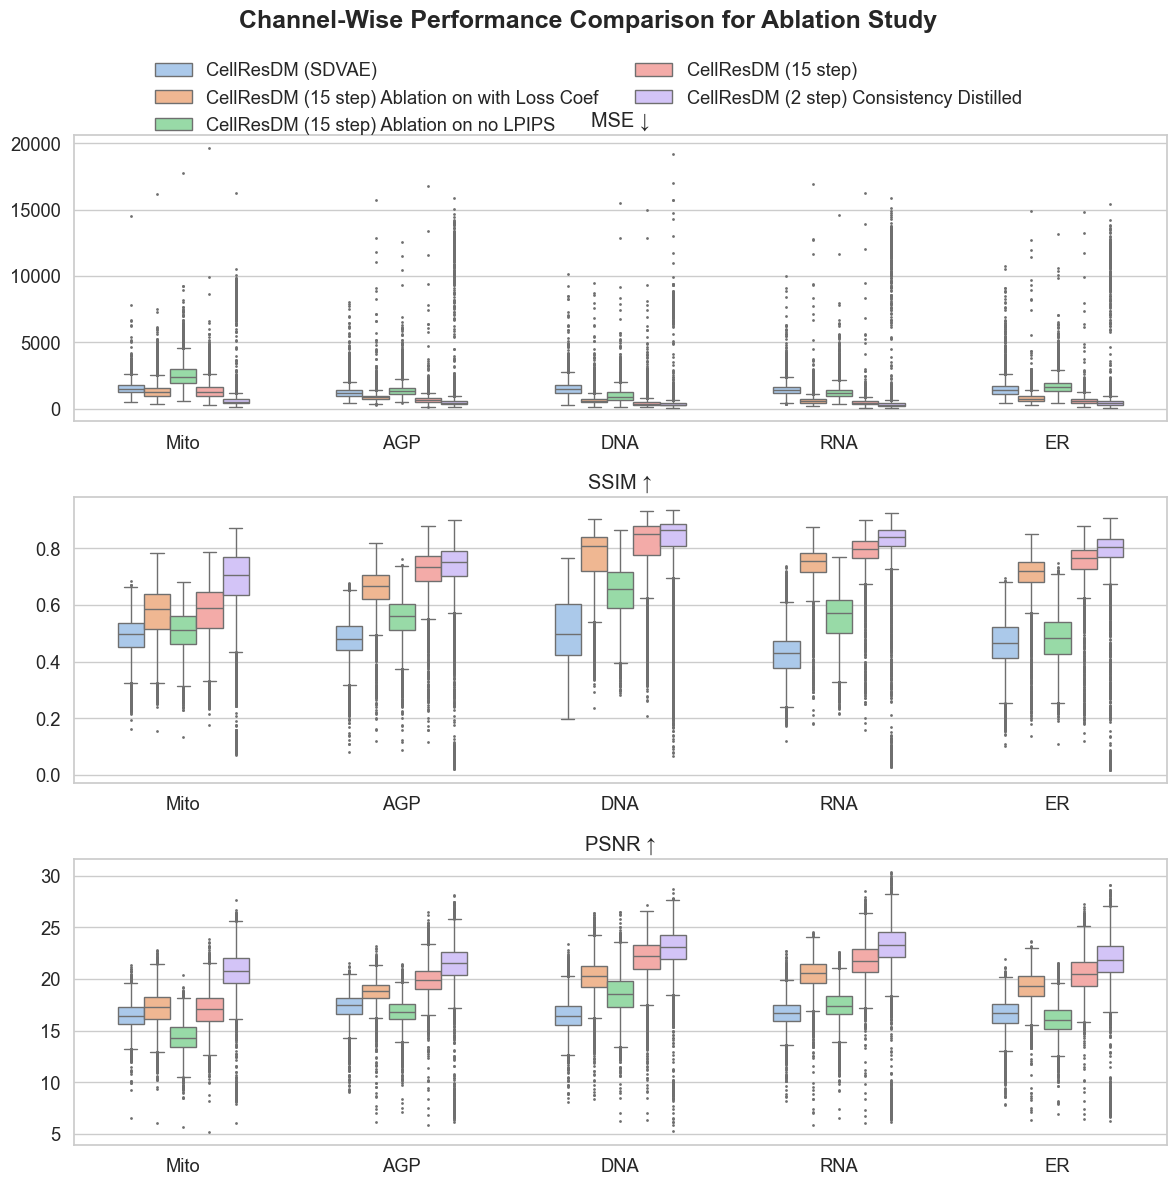

In [10]:
import pandas as pd



df2 = pd.read_csv('./results/metrics_CellResDM_SDVAE_125.csv')
df2['model'] = 'CellResDM (SDVAE)'
df2['channel'] = df2['channel'].map({2: 4, 0:0, 1:1})

df3 = pd.read_csv('./results/metrics_CellResDM_SDVAE_345.csv')
df3['model'] = 'CellResDM (SDVAE)'
df3['channel'] = df3['channel'].map({0: 2, 1: 3, 2: 4})
df3
df3 = df3[df3['channel'] != 4]
# concatenate df2 and df3
df_cellresdm_sdvae = pd.concat([df2, df3])
df_cellresdm_sdvae


df6 = pd.read_csv('./results/metrics_final_corrected_version_15step_with_coef.csv')
df6['model'] = 'CellResDM (15 step) Ablation on with Loss Coef'

df7 = pd.read_csv('./results/metrics_final_corrected_version_15step_no_lpips.csv')
df7['model'] = 'CellResDM (15 step) Ablation on no LPIPS'

df8 = pd.read_csv('./results/metrics_final_corrected_version_15step.csv')
df8['model'] = 'CellResDM (15 step)'


df9 = pd.read_csv('./results/metrics_one_step.csv')
df9['model'] = 'CellResDM (2 step) Consistency Distilled'




# df6 = pd.read_csv('../metrics 15step cd.csv')
# df6['model'] = 'ResCell (15 step, wo Loss Coef, MSE+LPIPS CD)'

df = pd.concat([df_cellresdm_sdvae, df6, df7, df8, df9], ignore_index=True)

# first print the mean per model per metric
display(df.groupby('model')[['mse_255', 'ssim_255', 'psnr_255']].mean())
display(df.groupby('model')[['mse_255', 'ssim_255', 'psnr_255']].std())

channel_map = {
    0: "Mito", 1: "AGP", 2: "RNA", 3: "ER", 4: "DNA"
}
df['channel'] = df['channel'].map(channel_map)

# If some channels are missing, drop NA
df = df.dropna(subset=['channel'])

metrics = {'mse_255': "MSE ↓", 'ssim_255': 'SSIM ↑', 'psnr_255' : 'PSNR ↑'}


import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.2)

fig, ax = plt.subplots(3, 1, figsize=(12, 12))
for idx, metric in enumerate(['mse_255', 'ssim_255', 'psnr_255']):
    sns.boxplot(x='channel', y=metric, hue = 'model', data=df, palette='pastel', showfliers=True, ax=ax[idx], fliersize = 1., width = 0.6)
    ax[idx].set_title(f'{metrics[metric]}')
    ax[idx].set_xlabel('')
    ax[idx].set_ylabel('')
    # disable legend
    ax[idx].legend_.remove()
    # sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    # title="Channel-Wise Performance Comparison",
    loc="upper center",
    ncol=len(df.model.unique())/2,  # Divide by 2 to create 2 rows
    frameon=False,
    bbox_to_anchor=(0.5, 0.96)
)
fig.suptitle("Channel-Wise Performance Comparison for Ablation Study", fontsize=18, fontweight="bold", y=0.99)

# ----------------------------------------------------------------------------
# 6) ADJUST LAYOUT SO LEGEND SITS ABOVE
# ----------------------------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave top 7% for legend
plt.show()


In [11]:
df = pd.read_csv('./results/metrics_unet.csv')
df['model'] = 'Unet'
df

,timestamp,image_name,channel,mse,ssim,psnr,mse_255,ssim_255,psnr_255,model
0,2025-05-30 22:41:41,/home/ym429/rds/hpc-work/dissertation/BR001169...,0,0.011745,0.665699,19.301431,763.72560,0.665699,19.301430,Unet
1,2025-05-30 22:41:42,/home/ym429/rds/hpc-work/dissertation/BR001169...,1,0.008799,0.610318,20.555445,572.18420,0.610318,20.555445,Unet
2,2025-05-30 22:41:42,/home/ym429/rds/hpc-work/dissertation/BR001169...,2,0.007496,0.655344,21.251710,487.42676,0.655344,21.251710,Unet
3,2025-05-30 22:41:42,/home/ym429/rds/hpc-work/dissertation/BR001169...,3,0.009008,0.605128,20.453488,585.77600,0.605128,20.453488,Unet
4,2025-05-30 22:41:42,/home/ym429/rds/hpc-work/dissertation/BR001169...,4,0.015202,0.473169,18.181038,988.49994,0.473169,18.181038,Unet
...,...,...,...,...,...,...,...,...,...,...
69115,2025-05-30 23:44:23,/home/ym429/rds/hpc-work/dissertation/BR001180...,0,0.014701,0.558380,18.326391,955.96350,0.558380,18.326391,Unet
69116,2025-05-30 23:44:23,/home/ym429/rds/hpc-work/dissertation/BR001180...,1,0.011530,0.603539,19.381609,749.75520,0.603539,19.381609,Unet
69117,2025-05-30 23:44:23,/home/ym429/rds/hpc-work/dissertation/BR001180...,2,0.009077,0.705624,20.420390,590.25726,0.705624,20.420390,Unet
69118,2025-05-30 23:44:23,/home/ym429/rds/hpc-work/dissertation/BR001180...,3,0.013786,0.596124,18.605461,896.46690,0.596124,18.605461,Unet


In [15]:
import pandas as pd

df = pd.read_csv('./results/metrics_unet.csv')
df['model'] = 'Unet'

df1 = pd.read_csv('./results/metrics_pix2pix.csv')
df1['model'] = 'pix2pix'

df2 = pd.read_csv('./results/metrics_deephsc.csv')
df2['model'] = 'DeepHSC'

df8 = pd.read_csv('./results/metrics_final_corrected_version_15step.csv')
df8['model'] = 'CellResDM (15 step)'

df9 = pd.read_csv('./results/metrics_one_step.csv')
df9['model'] = 'CellResDM (2 step) Consistency Distilled'

for _df in [df, df1, df2, df8, df9]:
    _df['out_of_distribution'] = _df['image_name'].str.contains('BR00118041') | _df['image_name'].str.contains('BR00118045')

df = pd.concat([df, df1, df2, df8, df9], ignore_index=True)

# Add distribution type for easier plotting
df['distribution_type'] = df['out_of_distribution'].map({True: 'Out-of-Distribution', False: 'In-Distribution'})

# Print mean and std for overall performance
print("Overall Performance:")
display(df.groupby('model')[['mse_255', 'ssim_255', 'psnr_255']].mean())
display(df.groupby('model')[['mse_255', 'ssim_255', 'psnr_255']].std())

print("\nIn-Distribution vs Out-of-Distribution Performance:")
display(df.groupby(['model', 'distribution_type'])[['mse_255', 'ssim_255', 'psnr_255']].mean())

# Calculate difference between in-distribution and out-of-distribution performance
in_dist_means = df[df['distribution_type'] == 'In-Distribution'].groupby('model')[['mse_255', 'ssim_255', 'psnr_255']].mean()
out_dist_means = df[df['distribution_type'] == 'Out-of-Distribution'].groupby('model')[['mse_255', 'ssim_255', 'psnr_255']].mean()

# Calculate the difference (Out-of-Distribution - In-Distribution)
performance_difference = out_dist_means - in_dist_means

print("\nPerformance Difference (Out-of-Distribution - In-Distribution):")
print("Positive values indicate worse performance on out-of-distribution data")
display(performance_difference)


Overall Performance:


,mse_255,ssim_255,psnr_255
model,,,
CellResDM (15 step),734.552612,0.727595,20.243149
CellResDM (2 step) Consistency Distilled,568.657275,0.767551,21.979214
DeepHSC,617.931932,0.793733,20.846888
Unet,1140.487330,0.622066,18.990290
pix2pix,1626.089031,0.433389,16.436490


,mse_255,ssim_255,psnr_255
model,,,
CellResDM (15 step),543.328039,0.118800,2.486131
CellResDM (2 step) Consistency Distilled,1136.123761,0.125528,2.584149
DeepHSC,473.575185,0.103164,2.138335
Unet,1908.325426,0.100912,2.690378
pix2pix,829.496691,0.087337,1.834833



In-Distribution vs Out-of-Distribution Performance:


mse_255  \
model                                    distribution_type                  
CellResDM (15 step)                      In-Distribution       648.119382   
                                         Out-of-Distribution   821.010891   
CellResDM (2 step) Consistency Distilled In-Distribution       608.457127   
                                         Out-of-Distribution   520.621777   
DeepHSC                                  In-Distribution       556.399023   
                                         Out-of-Distribution   679.482675   
Unet                                     In-Distribution      1064.807349   
                                         Out-of-Distribution  1216.189244   
pix2pix                                  In-Distribution      1594.545591   
                                         Out-of-Distribution  1657.641613   

                                                              ssim_255  \
model                                    distribution_type               
CellResDM (15 step)                      In-Distribution      0.746447   
                                         Out-of-Distribution  0.708738   
CellResDM (2 step) Consistency Distilled In-Distribution      0.780226   
                                         Out-of-Distribution  0.752253   
DeepHSC                                  In-Distribution      0.827072   
                                         Out-of-Distribution  0.760384   
Unet                                     In-Distribution      0.614001   
                                         Out-of-Distribution  0.630133   
pix2pix                                  In-Distribution      0.414299   
                                         Out-of-Distribution  0.452484   

                                                               psnr_255  
model                                    distribution_type               
CellResDM (15 step)                      In-Distribution      20.691131  
                                         Out-of-Distribution  19.795038  
CellResDM (2 step) Consistency Distilled In-Distribution      22.431570  
                                         Out-of-Distribution  21.433254  
DeepHSC                                  In-Distribution      21.338236  
                                         Out-of-Distribution  20.355398  
Unet                                     In-Distribution      19.244472  
                                         Out-of-Distribution  18.736034  
pix2pix                                  In-Distribution      16.504648  
                                         Out-of-Distribution  16.368313


Performance Difference (Out-of-Distribution - In-Distribution):
Positive values indicate worse performance on out-of-distribution data


,mse_255,ssim_255,psnr_255
model,,,
CellResDM (15 step),172.891509,-0.037709,-0.896094
CellResDM (2 step) Consistency Distilled,-87.835351,-0.027973,-0.998316
DeepHSC,123.083652,-0.066688,-0.982838
Unet,151.381895,0.016131,-0.508438
pix2pix,63.096022,0.038185,-0.136335
